# Python第7次作业

针对“数据6.1”（在第6章中已详细介绍），我们以收入档次（V1）为响应变量，以工作年限（V2）、绩效考核得分（V3）和违规操作积分（V4）为特征变量，使用多分类神经网络算法进行拟合。

1. 变量设置及数据处理
2. 单隐藏层多分类问题神经网络算法
3. 双隐藏层多分类问题神经网络算法
4. 模型性能评价
5. 运用两个特征变量绘制多分类神经网络算法决策边界图

## 1. 变量设置与数据处理

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import cohen_kappa_score

In [2]:
data=pd.read_csv('../data/数据6.1.csv')
X = data.iloc[:, 1:]
y = data.iloc[:, 0]
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3, random_state=10)

In [3]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)
X_train_s = pd.DataFrame(X_train_s, columns=X_train.columns)
X_test_s = pd.DataFrame(X_test_s, columns=X_test.columns)

---

## 2. 单隐藏层多分类问题神经网络算法

### 2.1 训练模型

In [4]:
model = MLPClassifier(solver='sgd',learning_rate_init=0.01,learning_rate='constant',tol=0.0001,activation='relu',hidden_layer_sizes=(3,),random_state=10,max_iter=2000)
model.fit(X_train_s, y_train)
model.score(X_test_s, y_test)

0.9260450160771704

---

## 3. 双隐藏层多分类问题神经网络算法

### 3.1 训练模型

In [5]:
model = MLPClassifier(
    solver='sgd',
    learning_rate_init=0.01,
    learning_rate='constant',
    tol=0.0001,
    activation='relu',
    hidden_layer_sizes=(3,2),
    random_state=10,
    max_iter=2000
)
model.fit(X_train_s, y_train)
model.score(X_test_s, y_test)

0.7684887459807074

---

## 4. 模型性能评价

In [6]:
np.set_printoptions(suppress=True)
pred = model.predict(X_test_s)
pred[:5]

array([3, 2, 3, 2, 2])

In [7]:
print(confusion_matrix(y_test, pred))

[[  0  65   0]
 [  0 123   2]
 [  0   5 116]]


In [8]:
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           1       0.00      0.00      0.00        65
           2       0.64      0.98      0.77       125
           3       0.98      0.96      0.97       121

    accuracy                           0.77       311
   macro avg       0.54      0.65      0.58       311
weighted avg       0.64      0.77      0.69       311



/home/zql/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/zql/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/zql/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [9]:
cohen_kappa_score(y_test, pred)

0.6160362152337187

---

## 5. 运用两个特征变量绘制多分类神经网络算法决策边界图

In [10]:
X2_train_s = X_train_s.iloc[:, [1, 3]]
X2_test_s = X_test_s.iloc[:, [1, 3]]
model=MLPClassifier(solver='sgd',learning_rate_init=0.01,learning_rate='constant',tol=0.0001,activation='relu',hidden_layer_sizes=(3,2),random_state=10,max_iter=2000)
model.fit(X2_train_s, y_train)
model.score(X2_test_s, y_test)

0.8135048231511254

/home/zql/.local/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(


Text(0.5, 1.0, '多分类神经网络算法决策边界')

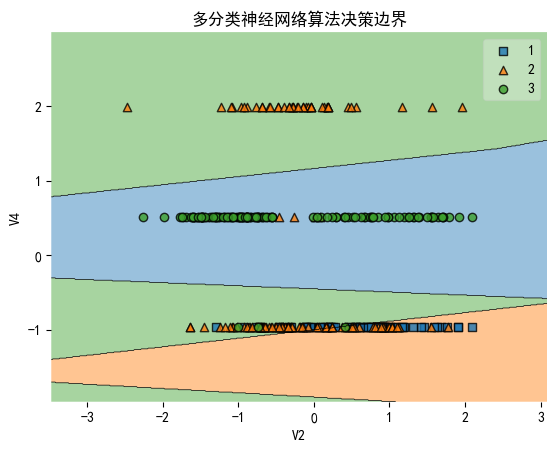

In [12]:
plt.rcParams['font.sans-serif']=['SimHei']
plt.rcParams['axes.unicode_minus']=False
plot_decision_regions(np.array(X2_test_s),np.array(y_test),model)
plt.xlabel('V2')
plt.ylabel('V4')
plt.title('多分类神经网络算法决策边界')